In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from matplotlib import pyplot
from numpy import where

# File path
csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\HomeA_unsupervised_real_combined_data.csv"

# Load the data from the CSV file
data = pd.read_csv(csv_file_path)

############################################
# Split the data into features and target
#X = data.drop(columns=['Label'])
#y = data['Label']

# Normalize the data using MinMaxScaler
#scaler = MinMaxScaler()
#X_scaled = scaler.fit_transform(X)
###########################################

# Extract features (X) and target labels (y) from the loaded data
X = data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable
y = data["Label"]  # Replace "target_column_name" with the actual column name for the target variable

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (52560, 1380)
y shape: (52560,)


In [31]:
# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
X_scaled

array([[0.05135521, 0.06213965, 0.04476893, ..., 0.03454099, 0.02916795,
        0.03162419],
       [0.0256776 , 0.02530429, 0.05006418, ..., 0.05511207, 0.05680074,
        0.05511207],
       [0.13060707, 0.12299808, 0.10799101, ..., 0.11344796, 0.11544366,
        0.11221983],
       ...,
       [0.06070693, 0.05813581, 0.05648267, ..., 0.06908198, 0.05142769,
        0.04912496],
       [0.13377714, 0.15006406, 0.15372272, ..., 0.11007062, 0.12265889,
        0.1228124 ],
       [0.04612458, 0.0470852 , 0.06996149, ..., 0.12803193, 0.13847099,
        0.13248388]])

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [34]:
#y_train_1 = (y_train == 1)
#y_test_1 = (y_test == 1)

### Apply SMOTE on the Training Data:
#### Use the SMOTE class from the imbalanced-learn library to oversample the minority class in the training data.

In [35]:
from imblearn.over_sampling import SMOTE

# Create a SMOTE instance
smote = SMOTE(random_state=42)

# Apply SMOTE on the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [36]:
# define pipeline
# over = SMOTE(sampling_strategy=0.1)
# under = RandomUnderSampler(sampling_strategy=0.5)
# steps = [('o', over), ('u', under)]
# pipeline = Pipeline(steps=steps)

In [37]:
# transform the dataset
# X_train_resampled, y_train_resampled = pipeline.fit_resample(X_train, y_train)

In [38]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

Counter({0: 43800, 1: 8760})


In [39]:
# summarize the new class distribution
counter = Counter(y_train_resampled)
print(counter)

Counter({1: 35023, 0: 35023})


In [40]:
#y_train_1 = (y_train_resampled == 1)
#y_test_1 = (y_test == 1)

In [41]:
# summarize the new class distribution
counter = Counter(y_train_resampled)
print(counter)

Counter({1: 35023, 0: 35023})


In [42]:
#from sklearn.linear_model import SGDClassifier

#sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
#sgd_clf.fit(X_train, y_train_5)

In [43]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
# Train an MLP Classifier on the resampled data
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42)
mlp.fit(X_train_resampled, y_train_resampled)
#mlp = MLPClassifier(random_state=1, max_iter=300).fit(X_train_resampled, y_train_resampled)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42)

In [44]:
#mlp.predict(X_test[:5, :])
#mlp.predict_proba(X_test[:1])

# Make predictions on the test data
predictions = mlp.predict(X_test)

In [45]:
mlp.score(X_test, y_test)

0.9920091324200914

In [46]:
from sklearn.model_selection import cross_val_score
cross_val_score(mlp, X_train_resampled, y_train_resampled, cv=3, scoring="accuracy")

array([0.99391837, 0.99678787, 0.99413226])

### Performance Measures
#### Measuring Accuracy Using Cross-Validation

In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_index, test_index in skfolds.split(X_train_resampled, y_train_resampled):
    clone_mlp = clone(mlp)
    X_train_folds = X_train_resampled[train_index]
    y_train_folds = y_train_resampled[train_index]
    X_test_fold = X_train_resampled[test_index]
    y_test_fold = y_train_resampled[test_index]

    clone_mlp.fit(X_train_folds, y_train_folds)
    y_pred = clone_mlp.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))
    

0.9956315045612232
0.9953317058546405
0.9962309405516533


### Confusion Matrix

In [51]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(mlp, X_train_resampled, y_train_resampled, cv=3)

In [52]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_resampled, y_train_pred)

array([[34732,   291],
       [   63, 34960]], dtype=int64)

In [53]:
y_train_perfect_predictions = y_train_resampled  # pretend we reached perfection
confusion_matrix(y_train_resampled, y_train_perfect_predictions)

array([[35023,     0],
       [    0, 35023]], dtype=int64)

### Precision and Recall

In [54]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_resampled, y_train_pred)

0.9917449150378712

In [55]:
cm = confusion_matrix(y_train_resampled, y_train_pred)
cm[1, 1] / (cm[0, 1] + cm[1, 1])

0.9917449150378712

In [56]:
recall_score(y_train_resampled, y_train_pred)

0.9982011820803472

In [57]:
cm[1, 1] / (cm[1, 0] + cm[1, 1])

0.9982011820803472

In [58]:
from sklearn.metrics import f1_score

f1_score(y_train_resampled, y_train_pred)

0.9949625750633235

In [59]:
cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)

0.9949625750633235

### Precision/Recall Trade-off

In [60]:
#y_scores = mlp.decision_function([some_digit])
y_scores = mlp.predict_proba(X_test)
y_scores

array([[0.00000000e+00, 1.00000000e+00],
       [9.97625420e-01, 2.37457996e-03],
       [1.00000000e+00, 1.17275924e-30],
       ...,
       [1.00000000e+00, 1.29381984e-23],
       [2.62012634e-14, 1.00000000e+00],
       [1.00000000e+00, 1.08517361e-22]])

In [61]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [62]:
y_some_digit_pred

array([[False,  True],
       [ True,  True],
       [ True,  True],
       ...,
       [ True,  True],
       [ True,  True],
       [ True,  True]])

In [63]:
threshold = 800
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([[False, False],
       [False, False],
       [False, False],
       ...,
       [False, False],
       [False, False],
       [False, False]])

In [64]:
#from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
#import numpy as np

# Create an instance of MLPClassifier
#mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=100)

# Example data (replace with your actual data)
#X_train_resampled = np.array(...)  # Your feature data
#X_train_resampled = np.array(X_train_resampled)  # Your feature data
#y_train_resampled = np.array(...)  # Your target data
#y_train_resampled = np.array(y_train_resampled)  # Your target data

# Use cross_val_predict to get predicted probabilities
y_probabilities = cross_val_predict(mlp, X_train_resampled, y_train_resampled, cv=3,
                                     method="predict_proba")

# Assuming the positive class is labeled as 1
y_scores = y_probabilities[:, 1]  # Probability estimates for the positive class

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_train_resampled, y_scores)


In [65]:
#y_scores = cross_val_predict(mlp, X_train_resampled, y_train_resampled, cv=3,
#                             method="decision_function")

In [66]:
#from sklearn.metrics import precision_recall_curve

#precisions, recalls, thresholds = precision_recall_curve(y_train_resampled, y_scores)

In [68]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=12) 
    plt.xlabel("Threshold", fontsize=12)        
    plt.grid(True)                              
    plt.axis([-1, 1, 0, 1])             


In [69]:
recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

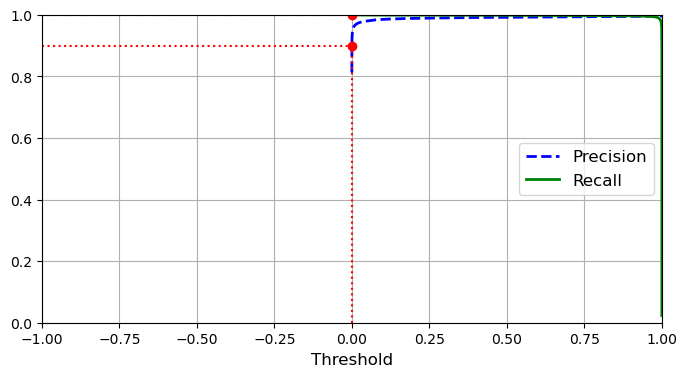

In [70]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))                                                                  
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")                 
plt.plot([-1, threshold_90_precision], [0.9, 0.9], "r:")                                
plt.plot([-1, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
plt.plot([threshold_90_precision], [0.9], "ro")                                             
plt.plot([threshold_90_precision], [recall_90_precision], "ro")                             
# save_fig("precision_recall_vs_threshold_plot")                                            
# plt.show()
plt.savefig("precision_recall_vs_threshold_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [71]:
(y_train_pred == (y_scores > 0)).all()

False

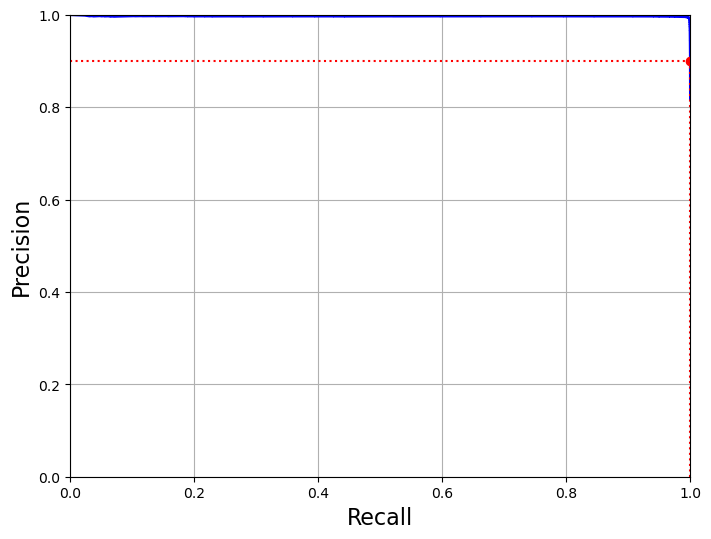

In [72]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_precision_vs_recall(precisions, recalls)
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
# save_fig("precision_vs_recall_plot")
# plt.show()
plt.savefig("precision_vs_recall_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [73]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

In [74]:
threshold_90_precision

0.0001471746446683959

In [75]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [76]:
precision_score(y_train_resampled, y_train_pred_90)

0.9000205613241493

In [77]:
recall_score(y_train_resampled, y_train_pred_90)

0.9998572366730434

### The ROC Curve

In [78]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_resampled, y_scores)

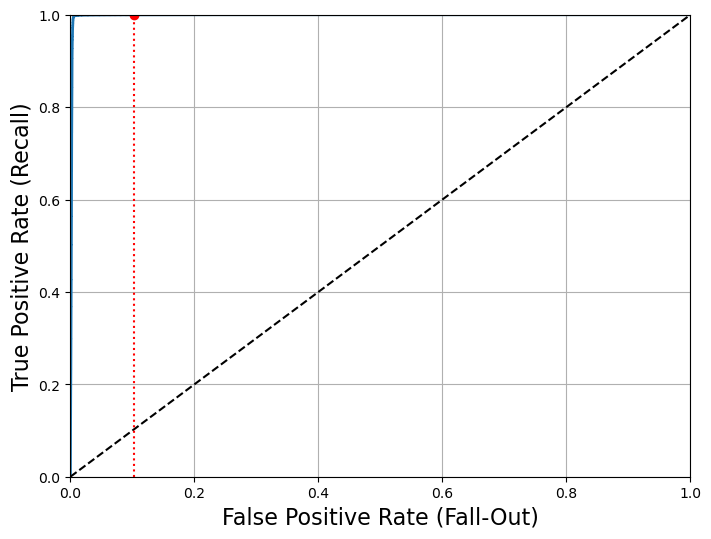

In [79]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])                                    
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16) 
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)    
    plt.grid(True)                                            

plt.figure(figsize=(8, 6))                                    
plot_roc_curve(fpr, tpr)
fpr_90 = fpr[np.argmax(tpr >= recall_90_precision)]           
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")   
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")  
plt.plot([fpr_90], [recall_90_precision], "ro")               
# save_fig("roc_curve_plot")                                    
# plt.show()
plt.savefig("roc_curve_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [80]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_resampled, y_scores)

0.998387059744536

### Now let's now train a RandomForestClassifier and compare its ROC curve and ROC AUC score to those of the SGDClassifier.¶

In [81]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train_resampled, y_train_resampled, cv=3,
                                    method="predict_proba")

In [82]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_resampled,y_scores_forest)

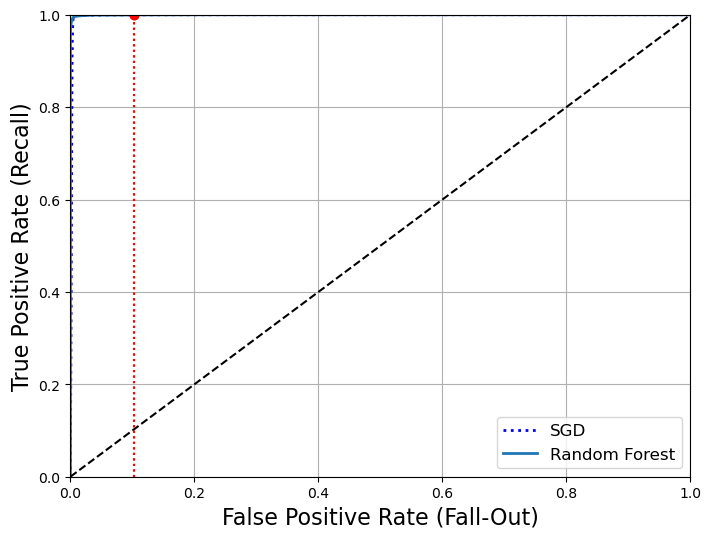

In [83]:
recall_for_forest = tpr_forest[np.argmax(fpr_forest >= fpr_90)]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.plot([fpr_90, fpr_90], [0., recall_90_precision], "r:")
plt.plot([0.0, fpr_90], [recall_90_precision, recall_90_precision], "r:")
plt.plot([fpr_90], [recall_90_precision], "ro")
plt.plot([fpr_90, fpr_90], [0., recall_for_forest], "r:")
plt.plot([fpr_90], [recall_for_forest], "ro")
plt.grid(True)
plt.legend(loc="lower right", fontsize=12)
# save_fig("roc_curve_comparison_plot")
# plt.show()
plt.savefig("roc_curve_comparison_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [84]:
roc_auc_score(y_train_resampled, y_scores_forest)

0.9998040881809518

In [85]:
y_train_pred_forest = cross_val_predict(forest_clf, X_train_resampled, y_train_resampled, cv=3)
precision_score(y_train_resampled, y_train_pred_forest)

0.9976379767254292

In [86]:
#sgd_clf.predict([some_digit])
#some_digit = X[0]
#mlp.predict([some_digit])
#mlp.predict()
############################
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
#X, y = make_classification(n_samples=100, random_state=1)
#X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
#                                                     random_state=1)
#clf = MLPClassifier(random_state=1, max_iter=300).fit(X_train, y_train)
#clf.predict_proba(X_test[:1])

#clf.predict(X_test[:5, :])

#clf.score(X_test, y_test)


In [87]:
# Predict the target on the testing data
y_test_pred = mlp.predict(X_test)

In [90]:
pd.crosstab(pd.Series(y_test_pred, name = 'Predicted'),
           pd.Series(y_test, name = 'Actual'))

Actual,0
Predicted,
0,1778
1,348


In [92]:
# Calculate performance metrics
report = classification_report(y_test, y_test_pred, target_names=['class_0', 'class_1'])
roc_auc = roc_auc_score(y_test, y_test_pred)

print("Classification Report:")
print(report)

print("ROC AUC Score:", roc_auc)

#This code uses the resampled data obtained from SMOTE to train an MLP Classifier and then evaluates its performance using various metrics. Note that this example assumes a binary classification problem; if you're dealing with a multi-class problem, you'll need to modify the code accordingly.

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00      8777
     class_1       0.98      0.98      0.98      1735

    accuracy                           0.99     10512
   macro avg       0.99      0.99      0.99     10512
weighted avg       0.99      0.99      0.99     10512

ROC AUC Score: 0.985734853899979


In [ ]:
#print("Number of features in training data:", X.shape[1])
#print("Number of features in test data:", y.shape[1])

In [ ]:
# summarize class distribution
counter = Counter(y)
print(counter)

In [ ]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")

save_fig("some_digit_plot")
plt.show()

In [ ]:
# transform the dataset
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [ ]:
# define pipeline
#over = SMOTE(sampling_strategy=0.1)
#under = RandomUnderSampler(sampling_strategy=0.5)
#steps = [('o', over), ('u', under)]
#pipeline = Pipeline(steps=steps)

In [ ]:
# transform the dataset
#X, y = pipeline.fit_resample(X, y)

In [ ]:
# summarize the new class distribution
counter = Counter(y)
print(counter)

In [ ]:
# Separate the target column (if available) from the training data
# Assuming the target column is the last column (change if not the case)
train_target = train_data.iloc[:, -1]
train_data = train_data.iloc[:, :-1]
#X = train_data.iloc[:, -1]
#y = train_data.iloc[:, :-1]


# Check for missing values in both datasets
#print("Number of missing values in training data:", train_data.isnull().sum().sum())
#print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
#column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder
#label_encoder = LabelEncoder()
#for column in train_data.columns:
#    if train_data[column].dtype == 'object':
#        train_data[column] = label_encoder.fit_transform(train_data[column])
#        test_data[column] = label_encoder.transform(test_data[column])

# Ensure the test data has the same set of columns as the training data
#extra_columns = set(test_data.columns) - set(column_names)
#if extra_columns:
#    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
#test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
#scaler = MinMaxScaler()
#train_data = scaler.fit_transform(train_data)
#test_data = scaler.transform(test_data)

# Convert back to DataFrames for easy evaluation
#train_data = pd.DataFrame(train_data, columns=column_names)
#test_data = pd.DataFrame(test_data, columns=column_names)


In [ ]:
# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

#input_dim = train_data.shape[1]
input_dim = X_train.shape[1]
autoencoder = build_autoencoder(input_dim)

In [ ]:
# Split the training data into training and validation sets
#X_train, X_val, y_train, y_val = train_test_split(train_data, train_data, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, X_train, test_size=0.2, random_state=42)

In [ ]:
# Train the MLP-AE model with validation data:
history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)

In [ ]:
# Access training loss values
training_loss = history.history['loss']
validation_loss = history.history['val_loss']


In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(training_loss) + 1), training_loss, label='Training Loss')
plt.plot(range(1, len(validation_loss) + 1), validation_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
#Use the trained model to make predictions:
train_preds = autoencoder.predict(train_data)
test_preds = autoencoder.predict(test_data)

In [ ]:
#Evaluate the model performance using the specified metrics:
#def evaluate_performance(y_true, y_pred):
#    accuracy = accuracy_score(y_true, y_pred.round())
#    precision = precision_score(y_true, y_pred.round())
#    recall = recall_score(y_true, y_pred.round())
#    tn, fp, fn, tp = confusion_matrix(y_true, y_pred.round()).ravel()
#    tnr = tn / (tn + fp)
#    fpr = fp / (tn + fp)
#    fnr = fn / (fn + tp)
#    f1 = f1_score(y_true, y_pred.round())
#    auc = roc_auc_score(y_true, y_pred)

#    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc
#######################################################################
# Define function for performance evaluation
def evaluate_performance(y_true, y_pred):
    mse = np.mean(np.square(y_true - y_pred), axis=1)
    # Assuming the threshold is 0.5 for anomaly detection (adjust if needed)
    anomaly_preds = (mse > 0.5).astype(int)
    
    accuracy = accuracy_score(y_true, anomaly_preds)
    precision = precision_score(y_true, anomaly_preds)
    recall = recall_score(y_true, anomaly_preds)
    tn, fp, fn, tp = confusion_matrix(y_true, anomaly_preds).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_true, anomaly_preds)
    auc = roc_auc_score(y_true, mse)
    
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

#######################################################################

# Assuming your target column is named 'Label' in the test_data DataFrame
test_target = test_data['Label'] if 'Label' in test_data else None
accuracy, precision, recall, tnr, fpr, fnr, f1, auc = evaluate_performance(test_target, test_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1-score:", f1)
print("AUC:", auc)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense

# Load the dataset
train_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Separate the target column (if available) from the training data
# Assuming the target column is the last column (change if not the case)
train_target = train_data.iloc[:, -1]
train_data = train_data.iloc[:, :-1]

# Check for missing values in both datasets
print("Number of missing values in training data:", train_data.isnull().sum().sum())
print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder (if any)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in train_data.columns:
    if train_data[column].dtype == 'object':
        train_data[column] = label_encoder.fit_transform(train_data[column])
        test_data[column] = label_encoder.transform(test_data[column])

# Ensure the test data has the same set of columns as the training data
extra_columns = set(test_data.columns) - set(column_names)
if extra_columns:
    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

input_dim = train_data.shape[1]
autoencoder = build_autoencoder(input_dim)

# Define function for performance evaluation
def evaluate_performance(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred.round())
    precision = precision_score(y_true, y_pred.round())
    recall = recall_score(y_true, y_pred.round())
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred.round()).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_true, y_pred.round())
    auc = roc_auc_score(y_true, y_pred)
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

# Perform k-fold cross-validation and evaluate the model
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = []

for train_index, val_index in kf.split(train_data):
    X_train, X_val = train_data[train_index], train_data[val_index]
    
    # Assuming your target column is named 'target' in the train_data DataFrame
    y_train, y_val = train_target[train_index], train_target[val_index]
    
    # Assuming your target column is named 'Label' in the train_data DataFrame
    #y_train, y_val = train_Label[train_index], train_Label[val_index]
    
    # Train the MLP-AE model with validation data:
    history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)
    
    # Use the trained model to make predictions on the validation data
    val_preds = autoencoder.predict(X_val)
    
    # Evaluate performance on the validation set
    fold_metrics.append(evaluate_performance(y_val, val_preds))

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(fold_metrics, axis=0)
std_metrics = np.std(fold_metrics, axis=0)

print("Mean Metrics:")
print("Accuracy:", mean_metrics[0])
print("Precision:", mean_metrics[1])
print("Recall:", mean_metrics[2])
print("TNR:", mean_metrics[3])
print("FPR:", mean_metrics[4])
print("FNR:", mean_metrics[5])
print("F1-score:", mean_metrics[6])
print("AUC:", mean_metrics[7])

print("\nStandard Deviation of Metrics:")
print("Accuracy:", std_metrics[0])
print("Precision:", std_metrics[1])
print("Recall:", std_metrics[2])
print("TNR:", std_metrics[3])
print("FPR:", std_metrics[4])
print("FNR:", std_metrics[5])
print("F1-score:", std_metrics[6])
print("AUC:", std_metrics[7])


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential, Model
from keras.layers import Input, Dense

# Load the dataset
train_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Separate the target column from the training data
train_target = train_data['Label']
train_data = train_data.drop(columns=['Label'])

# Check for missing values in both datasets
print("Number of missing values in training data:", train_data.isnull().sum().sum())
print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder (if any)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in train_data.columns:
    if train_data[column].dtype == 'object':
        train_data[column] = label_encoder.fit_transform(train_data[column])
        test_data[column] = label_encoder.transform(test_data[column])
        
# Ensure the test data has the same set of columns as the training data
extra_columns = set(test_data.columns) - set(column_names)
if extra_columns:
    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

input_dim = train_data.shape[1]
autoencoder = build_autoencoder(input_dim)

# Define function for performance evaluation
def evaluate_performance(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred.round())
    precision = precision_score(y_true, y_pred.round())
    recall = recall_score(y_true, y_pred.round())
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred.round()).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_true, y_pred.round())
    auc = roc_auc_score(y_true, y_pred)
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

# Perform k-fold cross-validation and evaluate the model
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = []

for train_index, val_index in kf.split(train_data):
    X_train, X_val = train_data[train_index], train_data[val_index]
    y_train, y_val = train_target[train_index], train_target[val_index]
    
    # Train the MLP-AE model with validation data:
    history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)
    
    # Use the trained model to make predictions on the validation data
    val_preds = autoencoder.predict(X_val)
    
    # Evaluate performance on the validation set
    fold_metrics.append(evaluate_performance(y_val, val_preds))

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(fold_metrics, axis=0)
std_metrics = np.std(fold_metrics, axis=0)

print("Mean Metrics:")
print("Accuracy:", mean_metrics[0])
print("Precision:", mean_metrics[1])
print("Recall:", mean_metrics[2])
print("TNR:", mean_metrics[3])
print("FPR:", mean_metrics[4])
print("FNR:", mean_metrics[5])
print("F1-score:", mean_metrics[6])
print("AUC:", mean_metrics[7])

print("\nStandard Deviation of Metrics:")
print("Accuracy:", std_metrics[0])
print("Precision:", std_metrics[1])
print("Recall:", std_metrics[2])
print("TNR:", std_metrics[3])
print("FPR:", std_metrics[4])
print("FNR:", std_metrics[5])
print("F1-score:", std_metrics[6])
print("AUC:", std_metrics[7])


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, f1_score
from keras.models import Sequential
from keras.layers import Dense

# Load the dataset
train_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Separate the target column from the training data
train_target = train_data['Label']
train_data = train_data.drop(columns=['Label'])

# Check for missing values in both datasets
print("Number of missing values in training data:", train_data.isnull().sum().sum())
print("Number of missing values in test data:", test_data.isnull().sum().sum())

# Store the column names for later use
column_names = train_data.columns

# Convert non-numeric values to numeric using LabelEncoder (if any)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in train_data.columns:
    if train_data[column].dtype == 'object':
        train_data[column] = label_encoder.fit_transform(train_data[column])
        test_data[column] = label_encoder.transform(test_data[column])
        
# Ensure the test data has the same set of columns as the training data
extra_columns = set(test_data.columns) - set(column_names)
if extra_columns:
    test_data.drop(columns=extra_columns, inplace=True)

# Handle missing values in the test dataset
test_data = test_data.fillna(0)  # You can use other imputation techniques based on your data

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

# Define the MLP-AE model:
def build_autoencoder(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(input_dim, activation='sigmoid'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

input_dim = train_data.shape[1]
autoencoder = build_autoencoder(input_dim)



In [ ]:
# Perform k-fold cross-validation and evaluate the model
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = []

for train_index, val_index in kf.split(train_data):
    X_train, X_val = train_data[train_index], train_data[val_index]
    y_train, y_val = train_target[train_index], train_target[val_index]
    
    # Train the MLP-AE model with validation data:
    history = autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, validation_data=(X_val, X_val), verbose=0)
    
    # Use the trained model to make predictions on the validation data
    val_preds = autoencoder.predict(X_val)
    
    # Calculate the mean squared error (MSE) between the true input and the autoencoder's output
    mse = np.mean(np.square(X_val - val_preds), axis=1)
    
    # Calculate the threshold for anomaly detection as the 95th percentile of MSE values
    threshold = np.percentile(mse, 95)
    
    # Perform anomaly detection based on the threshold
    anomaly_preds = (mse > threshold).astype(int)
    
###############################################################################
# Define function for performance evaluation
#def evaluate_performance(y_true, y_pred):
#    accuracy = accuracy_score(y_true, y_pred)
#    precision = precision_score(y_true, y_pred)
#    recall = recall_score(y_true, y_pred)
#    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
#    tnr = tn / (tn + fp)
#    fpr = fp / (tn + fp)
#    fnr = fn / (fn + tp)
#    f1 = f1_score(y_true, y_pred)
#    
#    # Calculate AUC if both positive and negative classes are present in the true labels
#    auc = roc_auc_score(y_true, mse) if len(np.unique(y_true)) == 2 else None
#    
#    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc

################################################################################
    # Evaluate performance on the validation set
#    accuracy = accuracy_score(y_val, anomaly_preds)
#    precision = precision_score(y_val, anomaly_preds)
#    recall = recall_score(y_val, anomaly_preds)
#    tn, fp, fn, tp = confusion_matrix(y_val, anomaly_preds).ravel()
#    tnr = tn / (tn + fp)
#    fpr = fp / (tn + fp)
#    fnr = fn / (fn + tp)
#    f1 = f1_score(y_val, anomaly_preds)
#    auc = roc_auc_score(y_val, mse) if len(np.unique(y_val)) == 2 else None
#    
#    fold_metrics.append((accuracy, precision, recall, tnr, fpr, fnr, f1, auc))
##############################################################################


In [ ]:
# Define function for performance evaluation
def evaluate_performance(y_val, y_pred):
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    tnr = tn / (tn + fp)
    fpr = fp / (tn + fp)
    fnr = fn / (fn + tp)
    f1 = f1_score(y_val, y_pred)
    
    # Calculate AUC if both positive and negative classes are present in the true labels
    auc = roc_auc_score(y_val, mse) if len(np.unique(y_val)) == 2 else -1
    
    return accuracy, precision, recall, tnr, fpr, fnr, f1, auc


# Convert fold_metrics to a numpy array
fold_metrics = np.array(fold_metrics)

# Filter out the rows where auc is None (when there is only one class in the validation data)
valid_auc_idx = fold_metrics[:, 7] != -1
valid_metrics = fold_metrics[valid_auc_idx]

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(valid_metrics, axis=0)
std_metrics = np.std(valid_metrics, axis=0)


################################################################################

# Calculate the mean and standard deviation of metrics across folds
mean_metrics = np.mean(fold_metrics, axis=0)
std_metrics = np.std(fold_metrics, axis=0)

print("Mean Metrics:")
print("Accuracy:", mean_metrics[0])
print("Precision:", mean_metrics[1])
print("Recall:", mean_metrics[2])
print("TNR:", mean_metrics[3])
print("FPR:", mean_metrics[4])
print("FNR:", mean_metrics[5])
print("F1-score:", mean_metrics[6])
print("AUC:", mean_metrics[7])

print("\nStandard Deviation of Metrics:")
print("Accuracy:", std_metrics[0])
print("Precision:", std_metrics[1])
print("Recall:", std_metrics[2])
print("TNR:", std_metrics[3])
print("FPR:", std_metrics[4])
print("FNR:", std_metrics[5])
print("F1-score:", std_metrics[6])
print("AUC:", std_metrics[7])
